<a href="https://colab.research.google.com/github/laylamoguibmm/Tasks/blob/main/task8_elevvopaths.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ============================================
# Traffic Sign Recognition with CNN + MobileNet
# ============================================

# Install required libraries
!pip install tensorflow opencv-python scikit-learn matplotlib pandas seaborn


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import cv2
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [7]:
# Paths to your files
train_path = '/content/drive/MyDrive/archive/train.p'
valid_path = '/content/drive/MyDrive/archive/valid.p'
test_path  = '/content/drive/MyDrive/archive/test.p'
signnames_path = '/content/drive/MyDrive/archive/signname.csv'

# Load data
with open(train_path, 'rb') as f:
    train_data = pickle.load(f)
with open(valid_path, 'rb') as f:
    valid_data = pickle.load(f)
with open(test_path, 'rb') as f:
    test_data = pickle.load(f)

signnames = pd.read_csv(signnames_path)

# Extract features and labels
X_train, y_train = train_data['features'], train_data['labels']
X_valid, y_valid = valid_data['features'], valid_data['labels']
X_test, y_test = test_data['features'], test_data['labels']

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)
print("Test set shape:", X_test.shape)


Training set shape: (34799, 32, 32, 3)
Validation set shape: (4410, 32, 32, 3)
Test set shape: (12630, 32, 32, 3)


In [8]:
# Resize and Normalize images
IMG_SIZE = 64

def preprocess_images(images):
    processed = []
    for img in images:
        img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        processed.append(img_resized)
    return np.array(processed)

X_train = preprocess_images(X_train)
X_valid = preprocess_images(X_valid)
X_test  = preprocess_images(X_test)

# Normalize
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test  = X_test / 255.0

# One-hot encode labels
num_classes = len(signnames)
y_train = to_categorical(y_train, num_classes)
y_valid = to_categorical(y_valid, num_classes)
y_test  = to_categorical(y_test, num_classes)

print("Data preprocessed successfully!")


Data preprocessed successfully!


In [9]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,
    fill_mode="nearest"
)
datagen.fit(X_train)


In [10]:
def build_custom_cnn(input_shape, num_classes):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    model.add(layers.Conv2D(32, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

custom_cnn = build_custom_cnn((IMG_SIZE, IMG_SIZE, 3), num_classes)
custom_cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,769,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,845,771 (10.86 MB)

 Trainable params: 2,845,771 (10.86 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Use smaller dataset for speed (optional)
subset_size = int(0.3 * len(X_train))  # 30% of data
X_train_small = X_train[:subset_size]
y_train_small = y_train[:subset_size]

history_cnn = custom_cnn.fit(
    X_train_small, y_train_small,
    validation_data=(X_valid, y_valid),
    epochs=5,  # reduced for speed
    batch_size=128,
    verbose=1
)


Epoch 1/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.2547 - loss: 2.5977 - val_accuracy: 0.2252 - val_loss: 7.4369
Epoch 2/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.7495 - loss: 0.7648 - val_accuracy: 0.2732 - val_loss: 15.9908
Epoch 3/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9311 - loss: 0.2363 - val_accuracy: 0.2857 - val_loss: 16.5850
Epoch 4/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9645 - loss: 0.1199 - val_accuracy: 0.2878 - val_loss: 17.0657
Epoch 5/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.9770 - loss: 0.0822 - val_accuracy: 0.2937 - val_loss: 17.5066


Custom CNN Test Accuracy: 0.282422810792923
395/395 ━━━━━━━━━━━━━━━━━━━━ 46s 116ms/step


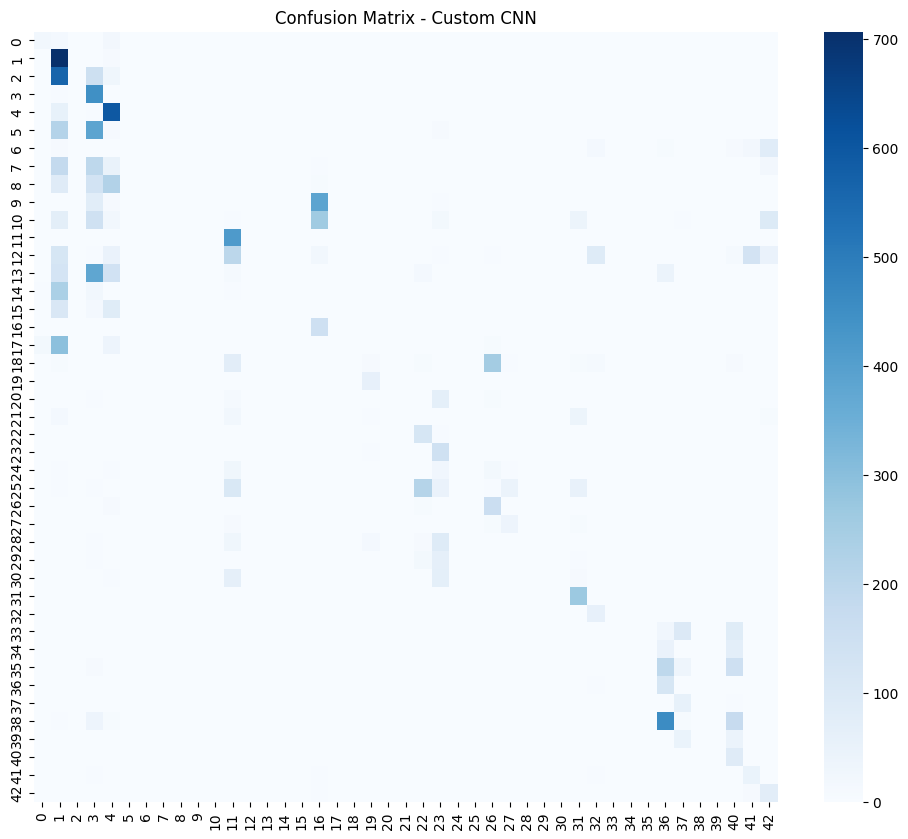

In [12]:
cnn_loss, cnn_acc = custom_cnn.evaluate(X_test, y_test, verbose=0)
print("Custom CNN Test Accuracy:", cnn_acc)

# Confusion Matrix
y_pred_cnn = np.argmax(custom_cnn.predict(X_test), axis=-1)
y_true = np.argmax(y_test, axis=-1)

cm = confusion_matrix(y_true, y_pred_cnn)
plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix - Custom CNN")
plt.show()


In [13]:
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = mobilenet_model.fit(datagen.flow(X_train, y_train, batch_size=64),
                                        validation_data=(X_valid, y_valid),
                                        epochs=3)


/tmp/ipython-input-926404798.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')


Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


544/544 ━━━━━━━━━━━━━━━━━━━━ 171s 304ms/step - accuracy: 0.3591 - loss: 2.3010 - val_accuracy: 0.4512 - val_loss: 1.7797
Epoch 2/3
544/544 ━━━━━━━━━━━━━━━━━━━━ 169s 310ms/step - accuracy: 0.5747 - loss: 1.3220 - val_accuracy: 0.4844 - val_loss: 1.7241
Epoch 3/3
544/544 ━━━━━━━━━━━━━━━━━━━━ 159s 293ms/step - accuracy: 0.6274 - loss: 1.1484 - val_accuracy: 0.4875 - val_loss: 1.7079


In [14]:
mb_loss, mb_acc = mobilenet_model.evaluate(X_test, y_test, verbose=0)
print("MobileNetV2 Test Accuracy:", mb_acc)

print("\nPerformance Comparison:")
print(f"Custom CNN Accuracy: {cnn_acc:.4f}")
print(f"MobileNetV2 Accuracy: {mb_acc:.4f}")

MobileNetV2 Test Accuracy: 0.5362628698348999

Performance Comparison:
Custom CNN Accuracy: 0.2824
MobileNetV2 Accuracy: 0.5363
